In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import pickle

from scipy.optimize import curve_fit
from scipy.signal import find_peaks

current_dir = '/home/marian/CIGAR_ANALYSIS/CIGAR/notebooks'

# Build the absolute path to ../functions
functions_path = os.path.abspath(os.path.join(current_dir, '../functions'))

# Add it to sys.path
sys.path.append(functions_path)

import parse_data 
import cigar as cig
import set_up as setup

from tqdm import tqdm


/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# colors = ['royalblue', 'crimson', 'black', 'green', 'darkorange', 'brown', 'coral', 'indigo', 'magenta', 'blue']
# Wong (2011) colorblind-safe palette – 8 distinct colors
# Works for deuteranopia, protanopia, and tritanopia

# Grayscale palette – 10 shades from near-black to light gray
# Paired with distinct markers and line styles for full grayscale legibility
GS_COLORS = [
    '#000000',  # Black
    '#1a1a1a',  # Near black
    '#333333',  # Very dark gray
    '#4d4d4d',  # Dark gray
    '#666666',  # Medium dark gray
    '#808080',  # Medium gray
    '#999999',  # Medium light gray
    '#b3b3b3',  # Light gray
    '#cccccc',  # Very light gray
    '#e6e6e6',  # Near white (use only on dark backgrounds)
]

CB_COLORS = [
    '#000000',  # Black
    '#E69F00',  # Orange
    '#56B4E9',  # Sky blue
    '#009E73',  # Bluish green
    '#F0E442',  # Yellow
    '#0072B2',  # Blue
    '#D55E00',  # Vermillion
    '#CC79A7',  # Reddish purple
    '#994F00',  # Brown        
    '#006CD1',  # Cerulean     
]

colors = GS_COLORS

# Distinct markers and line styles for extra redundancy (grayscale-safe)
CB_MARKERS    = ['o', 's', '^', 'D', 'v', 'P', '*', 'X']
CB_LINESTYLES = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-', '--', '-.', ':']


In [3]:


font_size = 20
# Configure matplotlib to use Computer Modern fonts and mathtext
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = font_size
     


##  Signal time constants

In [4]:
base        = f"/home/marian/CIGAR_ANALYSIS/CIGAR/data"
directory   = "NEXTHDDEMO"

In [5]:
h5_list = cig.read_directory(base, directory, file_type = 'h5')
h5_list

['/home/marian/CIGAR_ANALYSIS/CIGAR/data/NEXTHDDEMO/run_1365_0000_ldc1_trg0.waveforms.h5',
 '/home/marian/CIGAR_ANALYSIS/CIGAR/data/NEXTHDDEMO/run_1371_0000_ldc1_trg0.waveforms.h5',
 '/home/marian/CIGAR_ANALYSIS/CIGAR/data/NEXTHDDEMO/run_1369_0000_ldc1_trg0.waveforms.h5',
 '/home/marian/CIGAR_ANALYSIS/CIGAR/data/NEXTHDDEMO/run_1365_0006_ldc1_trg0.waveforms.h5',
 '/home/marian/CIGAR_ANALYSIS/CIGAR/data/NEXTHDDEMO/run_1365_0011_ldc1_trg0.waveforms.h5',
 '/home/marian/CIGAR_ANALYSIS/CIGAR/data/NEXTHDDEMO/run_1365_0008_ldc1_trg0.waveforms.h5',
 '/home/marian/CIGAR_ANALYSIS/CIGAR/data/NEXTHDDEMO/run_1366_0000_ldc1_trg0.waveforms.h5',
 '/home/marian/CIGAR_ANALYSIS/CIGAR/data/NEXTHDDEMO/run_1364_0000_ldc1_trg0.waveforms.h5',
 '/home/marian/CIGAR_ANALYSIS/CIGAR/data/NEXTHDDEMO/run_1365_0005_ldc1_trg0.waveforms.h5',
 '/home/marian/CIGAR_ANALYSIS/CIGAR/data/NEXTHDDEMO/run_1373_0000_ldc1_trg0.waveforms.h5',
 '/home/marian/CIGAR_ANALYSIS/CIGAR/data/NEXTHDDEMO/run_1365_0001_ldc1_trg0.waveforms.h5',

In [6]:
file_num = 6
top = 15

In [7]:
setup.check_h5(h5_list[file_num])

/home/marian/CIGAR_ANALYSIS/CIGAR/data/NEXTHDDEMO/run_1366_0000_ldc1_trg0.waveforms.h5 (File) ''
Last modif.: '2026-06-25T10:28:21+00:00'
Object Tree: 
/ (RootGroup) ''
/RD (Group) ''
/RD/fiber_baselines_hg (EArray(20, 36)bitshuffle, blosc:lz4(4)) ''
/RD/fiber_baselines_lg (EArray(20, 36)bitshuffle, blosc:lz4(4)) ''
/RD/fiberrwf_hg (EArray(20, 36, 14000)bitshuffle, blosc:lz4(4)) ''
/RD/fiberrwf_lg (EArray(20, 36, 14000)bitshuffle, blosc:lz4(4)) ''
/RD/sipmrwf (EArray(20, 832, 350)bitshuffle, blosc:lz4(4)) ''
/Run (Group) ''
/Run/events (Table(20,)bitshuffle, blosc:lz4(4)) ''
/Run/runInfo (Table(1,)bitshuffle, blosc:lz4(4)) ''
/Sensors (Group) ''
/Sensors/DataFiberHG (Table(36,)bitshuffle, blosc:lz4(4)) ''
/Sensors/DataFiberLG (Table(36,)bitshuffle, blosc:lz4(4)) ''
/Sensors/DataPMT (Table(0,)bitshuffle, blosc:lz4(4)) ''
/Sensors/DataSiPM (Table(832,)bitshuffle, blosc:lz4(4)) ''
/Trigger (Group) ''
/Trigger/configuration (Table(22,)bitshuffle, blosc:lz4(4)) ''
/Trigger/events (EArray(20

In [8]:
# ev_times = pd.read_hdf(h5_list[0], "/Run/events")
# sipm_info = pd.read_hdf(h5_list[0], "/Sensors/DataSiPM")

import tables

all_sipm_data = []
for h5_file in h5_list[:top]:
    with tables.open_file(h5_file, mode='r') as h5:
        all_sipm_data.append(h5.root.RD.fiberrwf_lg[:])

sipm_data = np.concatenate(all_sipm_data, axis=0)
print(sipm_data.shape)
print(sipm_data.dtype)
sipm_data = sipm_data.sum(axis=1)
print(sipm_data.shape)


(3903, 36, 14000)
int16
(3903, 14000)


In [9]:
sipm_data.shape[-1]

14000

In [10]:
350e-6/sipm_data.shape[-1]

2.5e-08

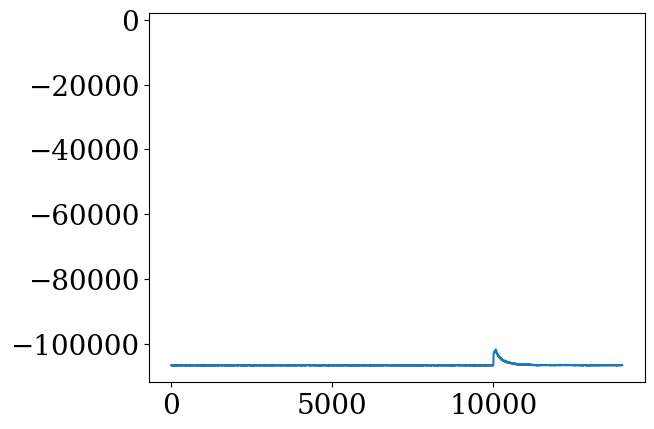

In [11]:
event = 77
# plt.plot(np.linspace(0, 350e-6, sipm_data.shape[-1]), -sipm_data[event][panel])
plt.plot(-sipm_data[event])
plt.hlines(-2961, 0, 350e-6)
# plt.ylim(-2980, -2955)
# plt.xlim(193e-6, 200e-6)
# plt.xlim(240e-6, 280e-6)
# plt.xlim(8.6e3, 9e3)
# plt.xlim(9e3, 11e3)

In [12]:
def rebin_to_us(wfsum: np.array, factor: int = 40) -> np.array:
    """
    Rebin waveform from 25 ns/bin to 1 µs/bin (factor of 40).
    Trims the array to a multiple of 40 before rebinning.
    """
    n_bins = len(wfsum) // factor          # number of complete 1µs bins
    trimmed = wfsum[:n_bins * factor]      # drop leftover samples if any
    rebinned = trimmed.reshape(n_bins, factor).sum(axis=1)
    return rebinned

In [13]:
old_bining = 25e-9 # [s] per bin
new_bining = 1e-6 # [s] per bin
# new_bining = 0.5e-6 # [s] per bin
rebin_factor = int(new_bining/old_bining)
print(f"REBIN FACTOR = {rebin_factor}")

REBIN FACTOR = 40


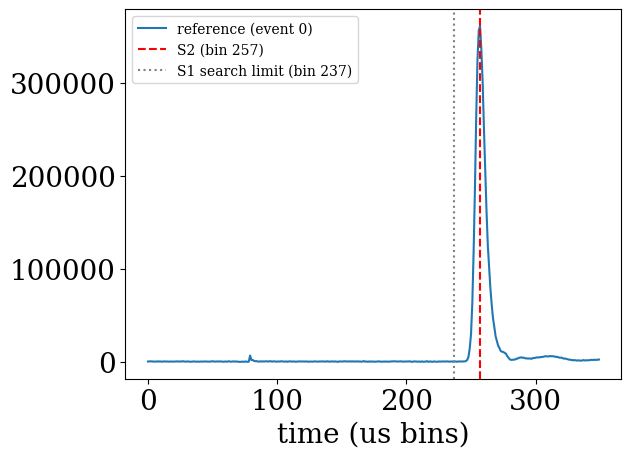

S2 at bin 257  |  S1 search window: [0, 237]


In [14]:
# Fixed S1 search window — derived once from the first event
# panel = 1
# ref_data     = -sipm_data[0][panel].astype(float)
# ref_data     = -sipm_data.sum(axis=1)[0].astype(float)
ref_data     = -sipm_data[0].astype(float)
ref_rebinned = rebin_to_us(ref_data, factor=rebin_factor)
ref_rebinned = ref_rebinned - np.median(ref_rebinned[:100])

ref_s2_idx   = np.argmax(ref_rebinned)
ref_half_max = ref_rebinned[ref_s2_idx] / 2
left_hw  = ref_s2_idx - np.where(ref_rebinned[:ref_s2_idx] < ref_half_max)[0][-1] if np.any(ref_rebinned[:ref_s2_idx] < ref_half_max) else ref_s2_idx
right_hw = np.where(ref_rebinned[ref_s2_idx:] < ref_half_max)[0][0]               if np.any(ref_rebinned[ref_s2_idx:] < ref_half_max) else len(ref_rebinned) - ref_s2_idx
search_limit = max(0, ref_s2_idx - 2 * (left_hw + right_hw))

plt.plot(ref_rebinned, label='reference (event 0)')
plt.axvline(ref_s2_idx,   color='red',  linestyle='--', label=f'S2 (bin {ref_s2_idx})')
plt.axvline(search_limit, color='gray', linestyle=':',  label=f'S1 search limit (bin {search_limit})')
plt.xlabel('time (us bins)')
plt.legend(fontsize=10)
plt.show()
print(f'S2 at bin {ref_s2_idx}  |  S1 search window: [0, {search_limit}]')


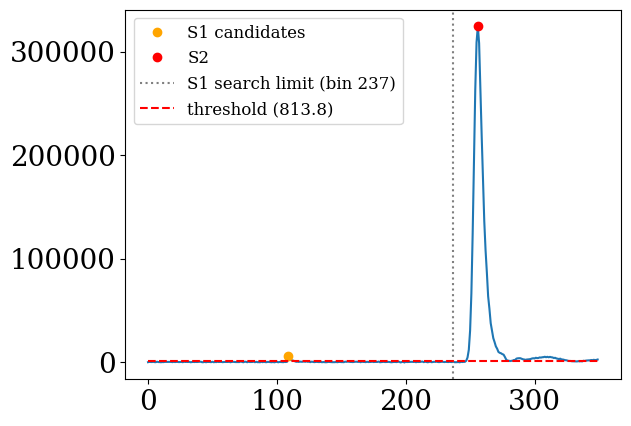

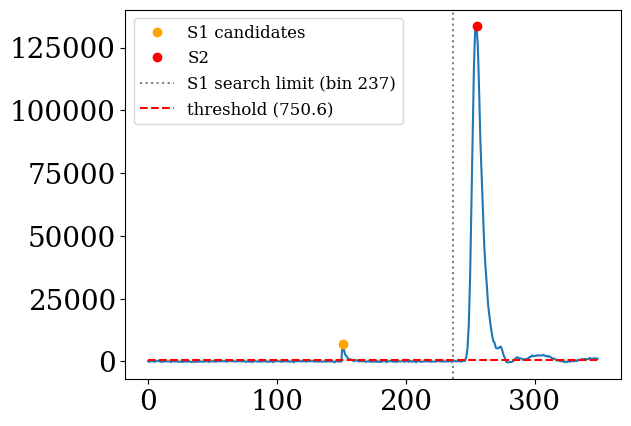

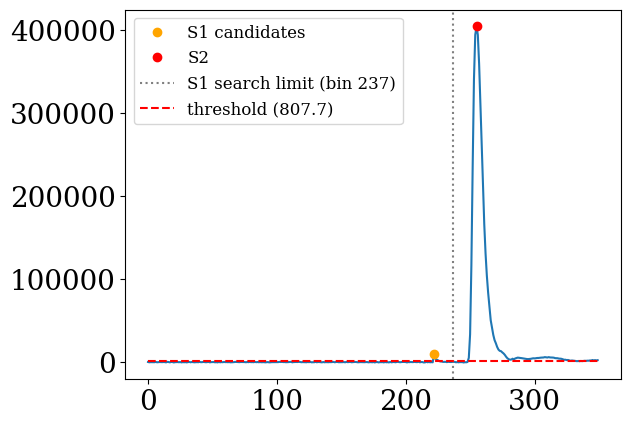

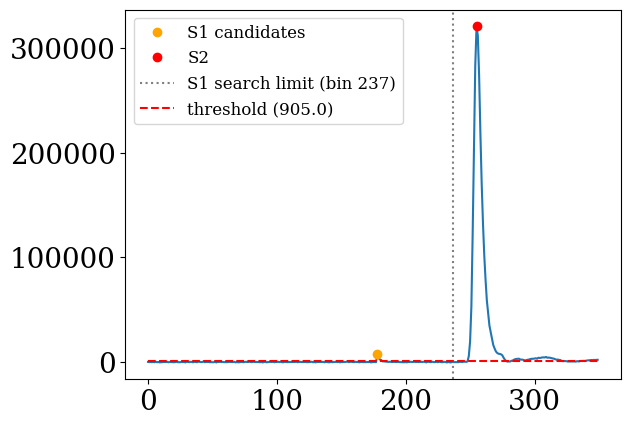

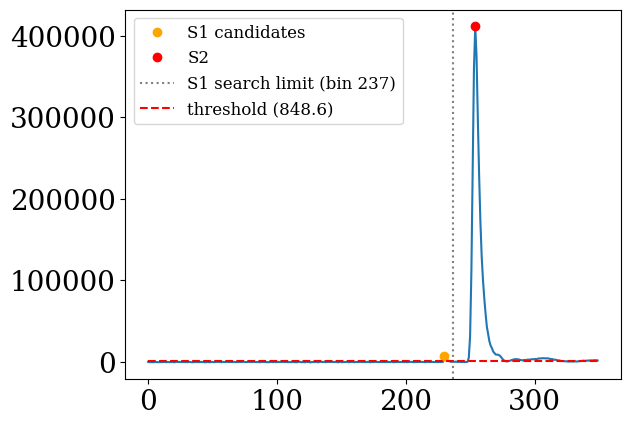

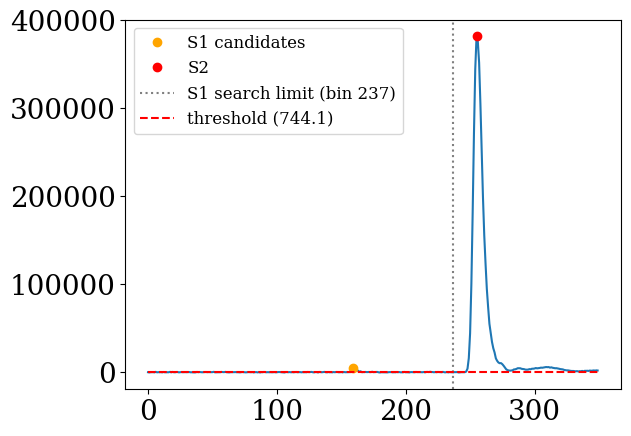

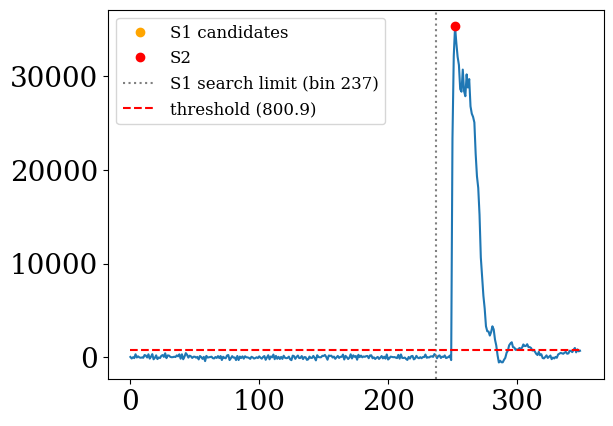

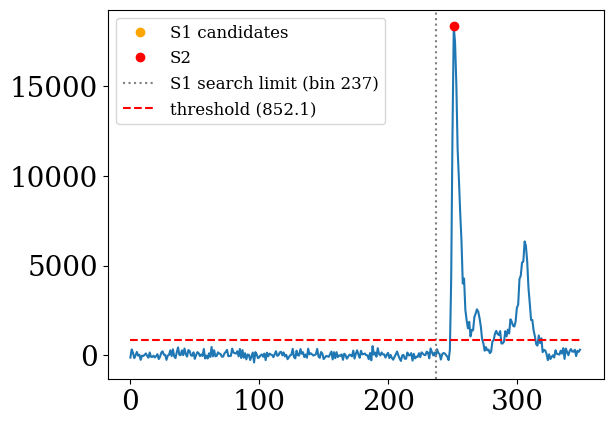

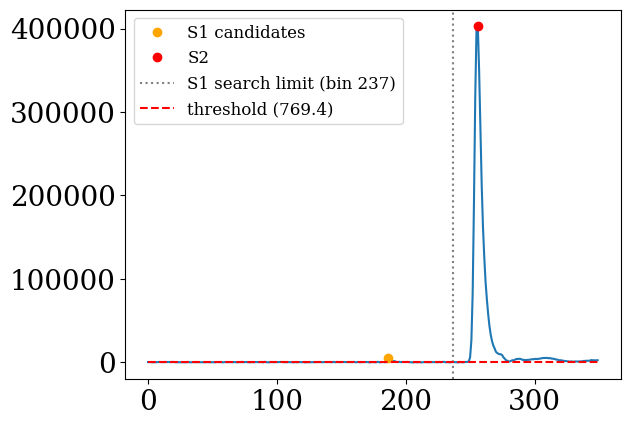

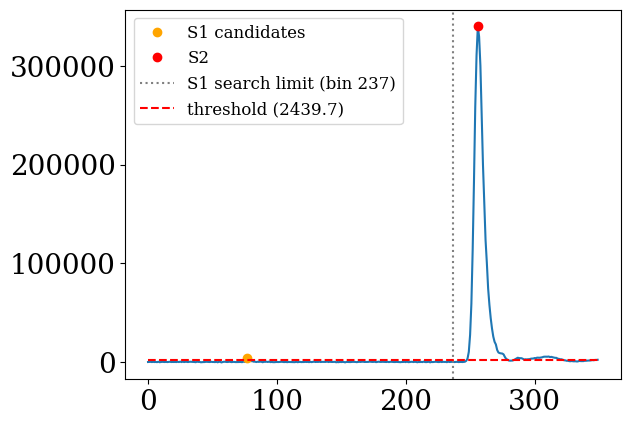

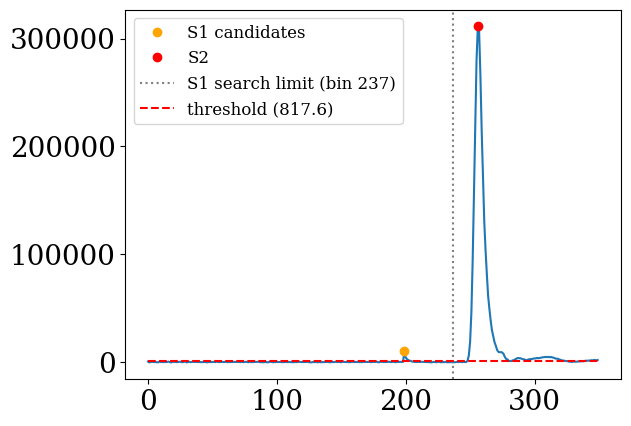

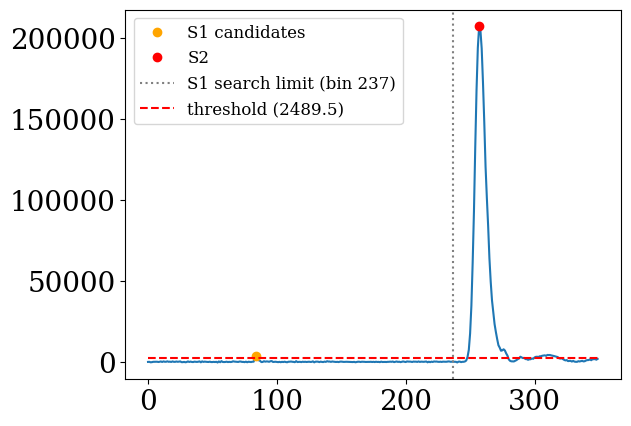

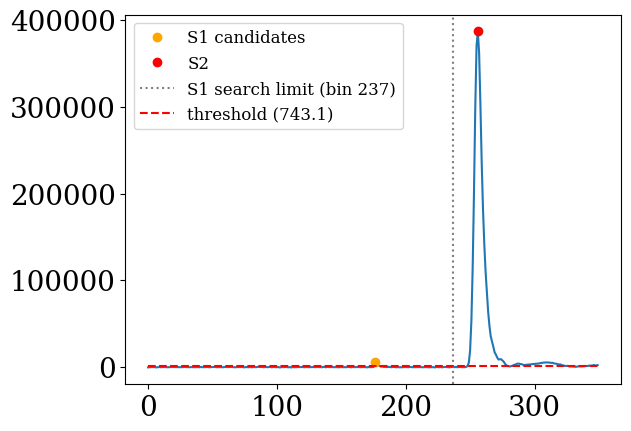

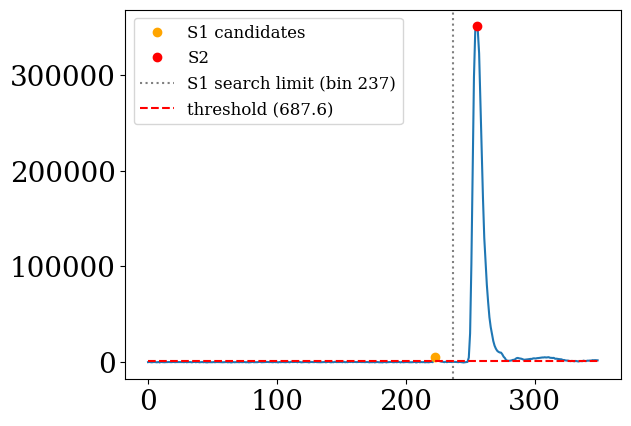

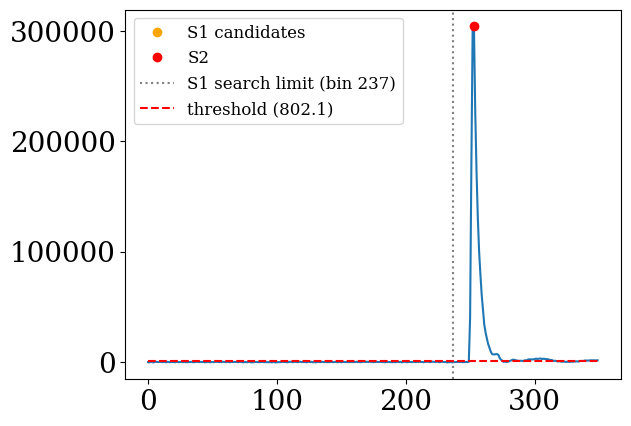

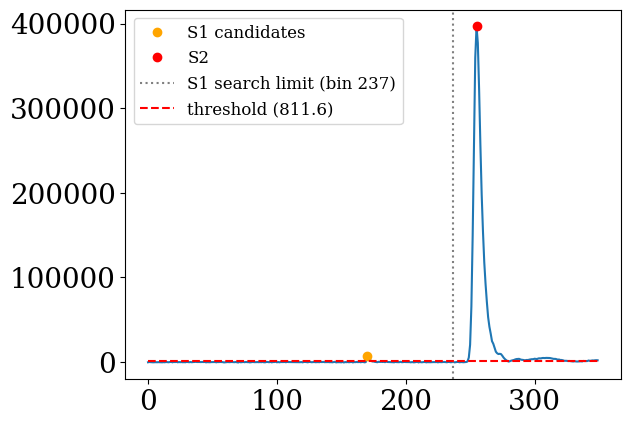

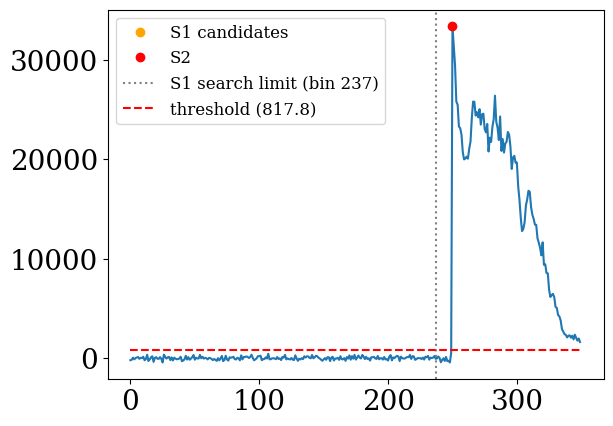

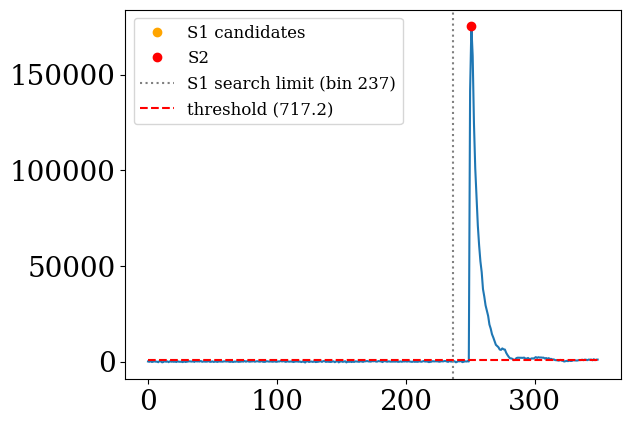

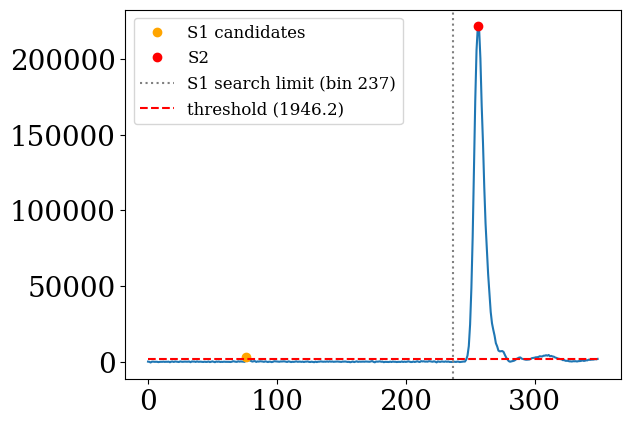

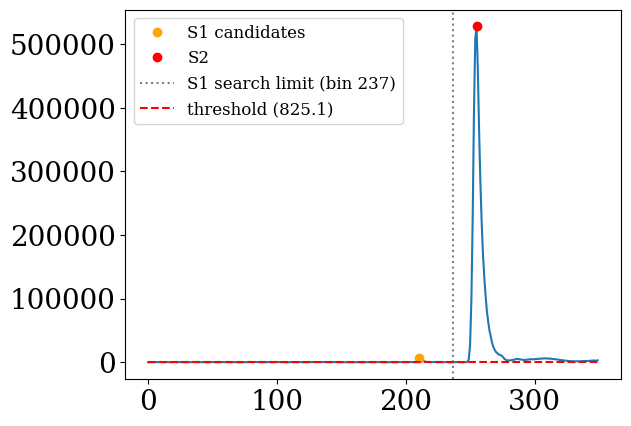

In [15]:
for event in range(60, 80):
# for event in [26]:
    # panel = 1
    # data = -sipm_data[event][panel]
    data = -sipm_data[event]
    rebinned_data = rebin_to_us(data, factor=rebin_factor)

    baseline_region = rebinned_data[:100]
    baseline = np.median(baseline_region)
    rebinned_data = rebinned_data - baseline

    bl_std = baseline_region.std()
    threshold = 5 * bl_std

    s2_idx = np.argmax(rebinned_data)

    peaks, _ = find_peaks(rebinned_data[:search_limit], height=threshold, distance=20)

    plt.plot(rebinned_data)
    plt.plot(peaks, rebinned_data[peaks], 'o', color='orange', label='S1 candidates')
    plt.plot(s2_idx, rebinned_data[s2_idx], 'o', color='red', label='S2')
    plt.axvline(search_limit, color='gray', linestyle=':', label=f'S1 search limit (bin {search_limit})')
    plt.hlines(threshold, 0, len(rebinned_data), color='r', linestyle='--', label=f'threshold ({threshold:.1f})')
    plt.legend(fontsize=12)
    plt.show()


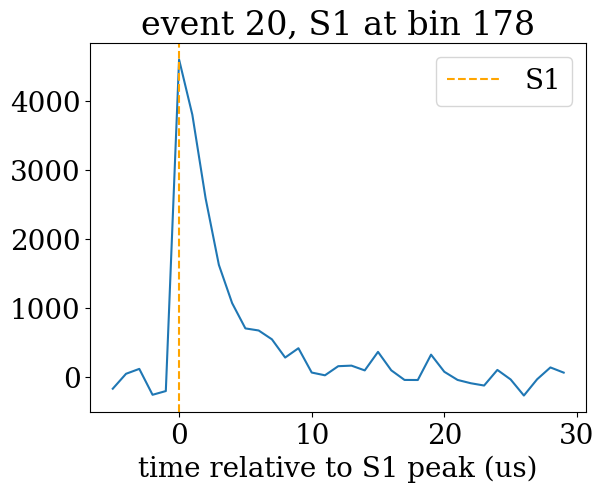

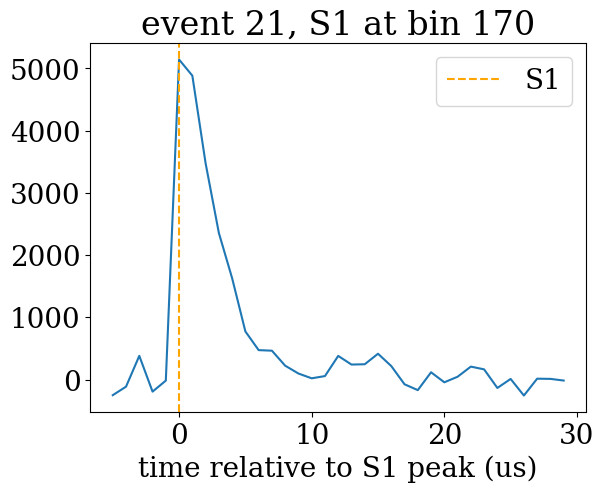

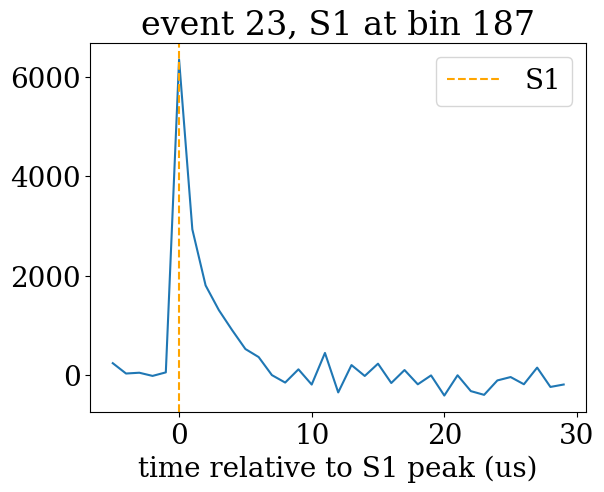

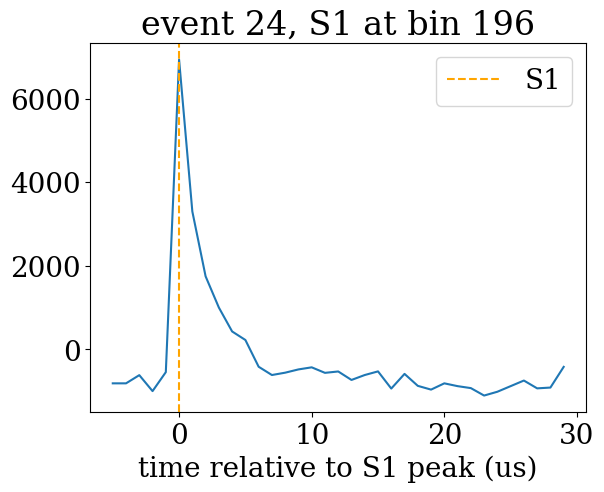

In [16]:
for event in range(20, 25):
    # panel = 1
    # data = -sipm_data[event][panel]
    data = -sipm_data[event]
    rebinned_data = rebin_to_us(data, factor=rebin_factor)

    baseline_region = rebinned_data[:100]
    baseline = np.median(baseline_region)
    rebinned_data = rebinned_data - baseline

    bl_std = baseline_region.std()
    threshold = 5 * bl_std

    s2_idx = np.argmax(rebinned_data)
    half_max = rebinned_data[s2_idx] / 2

    left_hw  = s2_idx - np.where(rebinned_data[:s2_idx] < half_max)[0][-1] if np.any(rebinned_data[:s2_idx] < half_max) else s2_idx
    right_hw = np.where(rebinned_data[s2_idx:] < half_max)[0][0]            if np.any(rebinned_data[s2_idx:] < half_max) else len(rebinned_data) - s2_idx
    fwhm = left_hw + right_hw
    search_limit = max(0, s2_idx - 2 * fwhm)

    peaks, _ = find_peaks(rebinned_data[:search_limit], height=threshold, distance=20)

    if len(peaks) == 0:
        continue

    for s1_idx in peaks:
        lo = max(0, s1_idx - 5)
        hi = min(len(rebinned_data), s1_idx + 30)
        window = rebinned_data[lo:hi]
        t = np.arange(lo, hi) - s1_idx  # time axis centered on S1

        plt.plot(t, window)
        plt.axvline(0, color='orange', linestyle='--', label='S1')
        plt.xlabel('time relative to S1 peak (us)')
        plt.title(f'event {event}, S1 at bin {s1_idx}')
        plt.legend()
        plt.show()


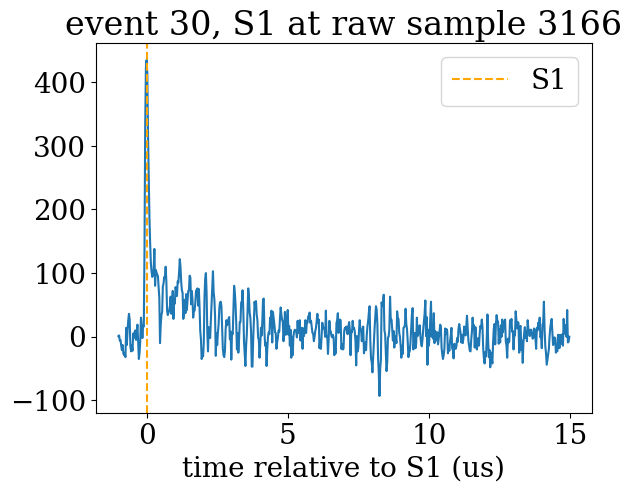

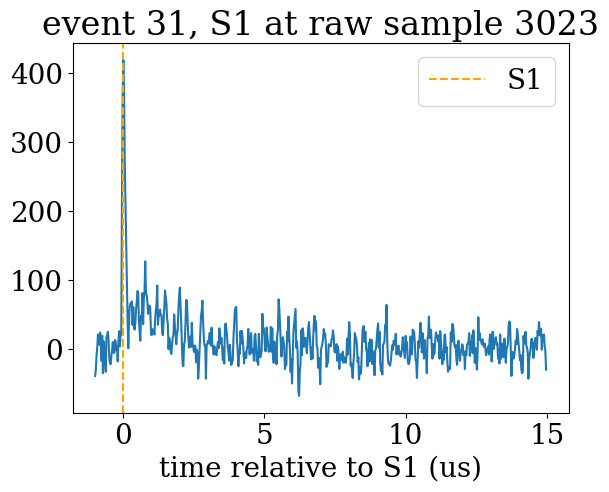

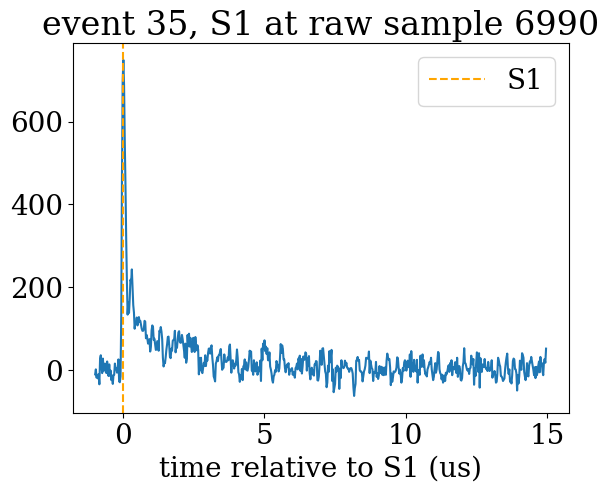

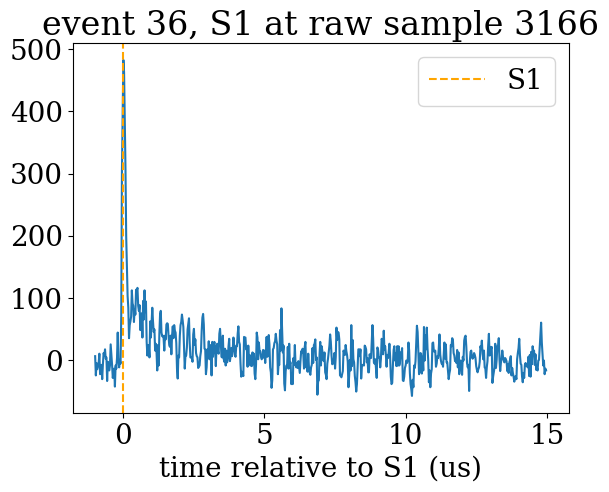

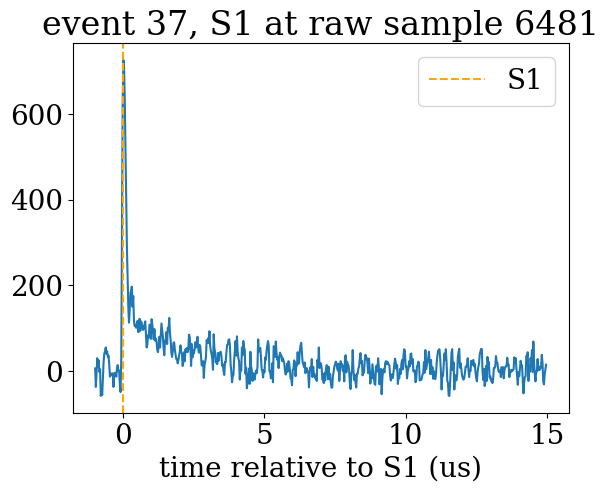

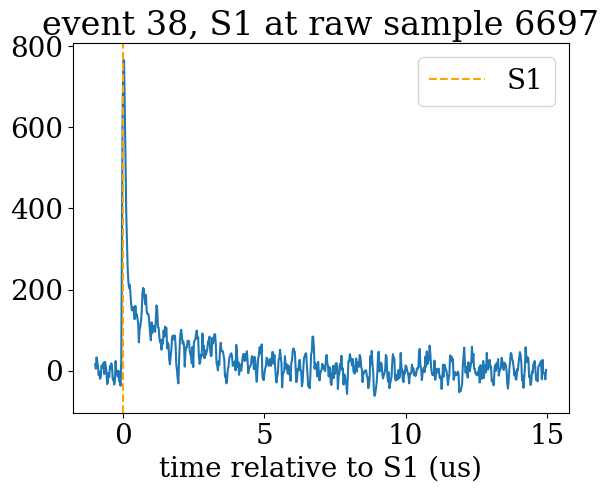

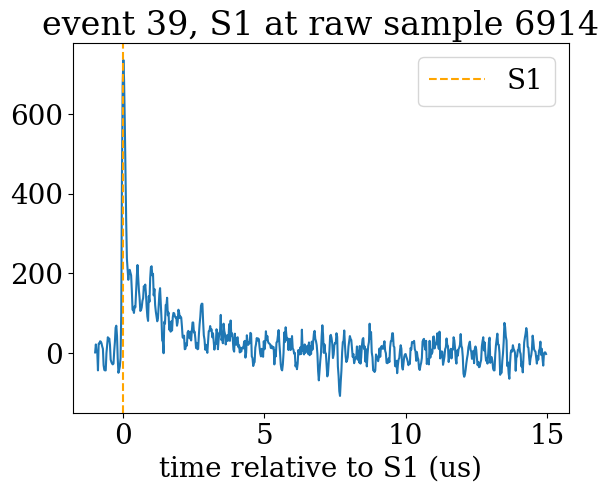

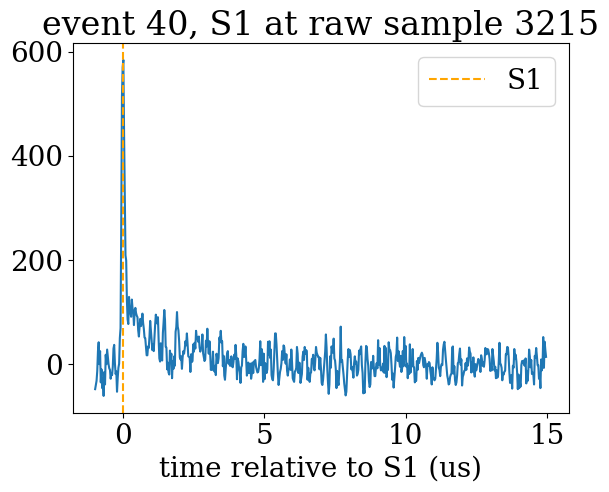

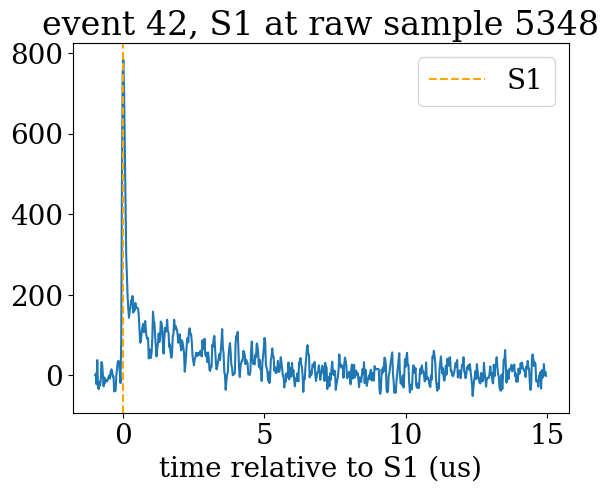

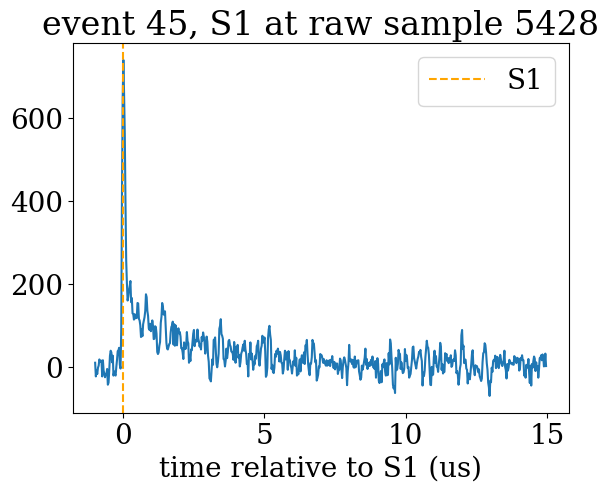

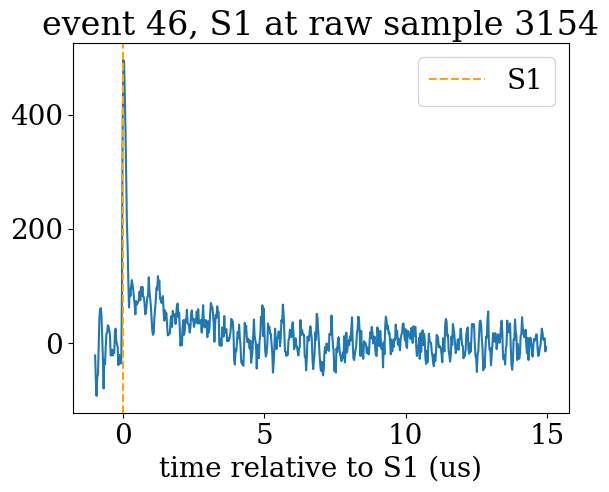

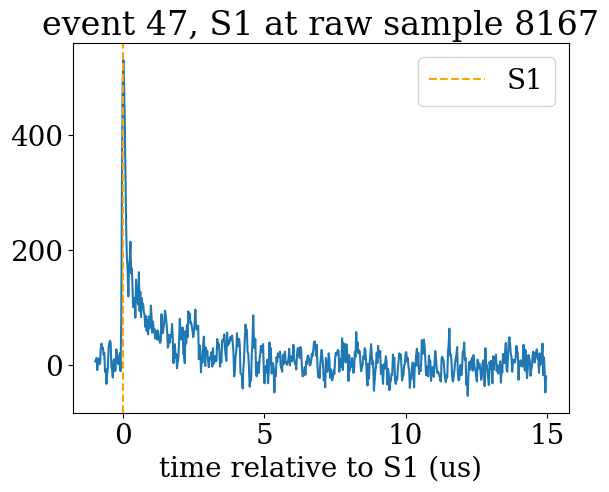

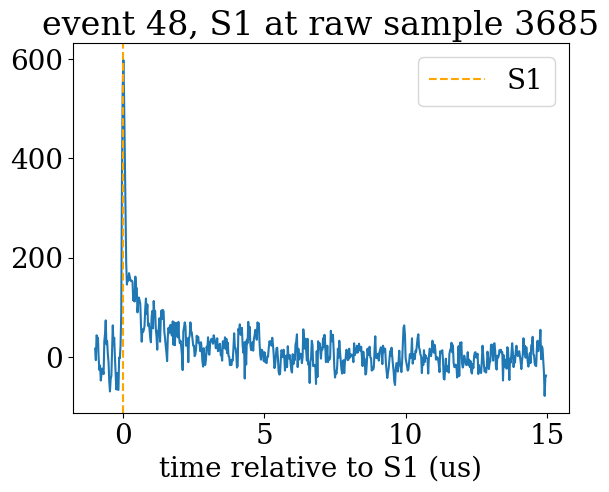

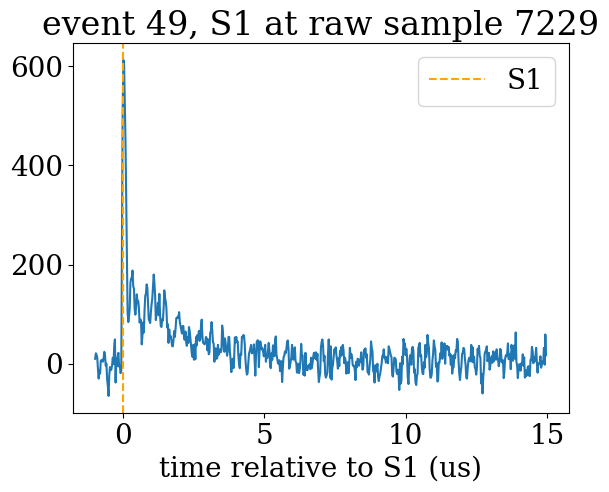

2901 S1 cut-outs collected


In [17]:
pre_us, post_us = 1, 15
plot_events = range(30, 50)

all_cuts = []

for event in range(sipm_data.shape[0]):
    # data = -sipm_data[event][panel].astype(float)
    data = -sipm_data[event].astype(float)
    rebinned_data = rebin_to_us(data, factor=rebin_factor)

    baseline_region = rebinned_data[:100]
    baseline = np.median(baseline_region)
    rebinned_data = rebinned_data - baseline

    threshold = 5 * baseline_region.std()

    peaks, _ = find_peaks(rebinned_data[:search_limit], height=threshold, distance=20)

    if len(peaks) == 0 or len(peaks) > 1:
        continue

    raw_baseline = np.median(data[:100 * rebin_factor])
    data = data - raw_baseline

    s1_idx = peaks[0]
    s1_raw_approx = s1_idx * rebin_factor
    search_lo = max(0, s1_raw_approx - rebin_factor)
    search_hi = min(len(data), s1_raw_approx + rebin_factor)
    s1_raw = search_lo + np.argmax(data[search_lo:search_hi])

    lo = s1_raw - pre_us  * rebin_factor
    hi = s1_raw + post_us * rebin_factor

    if lo < 0 or hi > len(data):
        continue

    window = data[lo:hi]
    all_cuts.append(window)

    if event in plot_events:
        t = np.arange(-pre_us * rebin_factor, post_us * rebin_factor) / rebin_factor
        plt.plot(t, window)
        plt.axvline(0, color='orange', linestyle='--', label='S1')
        plt.xlabel('time relative to S1 (us)')
        plt.title(f'event {event}, S1 at raw sample {s1_raw}')
        plt.legend()
        plt.show()

print(f'{len(all_cuts)} S1 cut-outs collected')


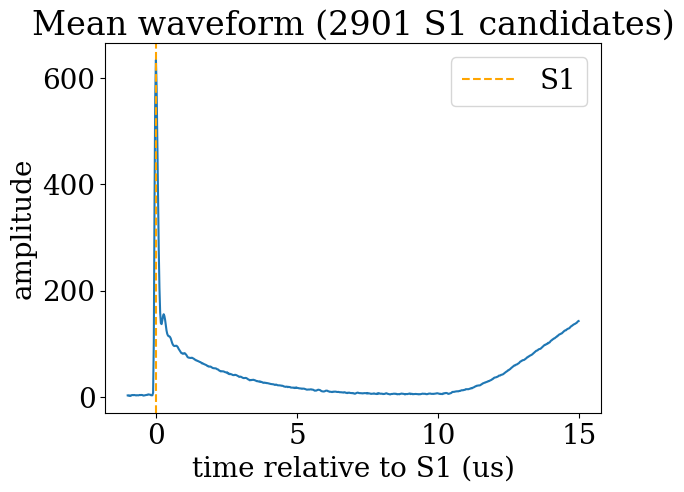

In [18]:
mean_wf = np.mean(all_cuts, axis=0)
t = np.arange(-pre_us * rebin_factor, post_us * rebin_factor) / rebin_factor  # us

plt.plot(t, mean_wf)
plt.axvline(0, color='orange', linestyle='--', label='S1')
plt.xlabel('time relative to S1 (us)')
plt.ylabel('amplitude')
plt.title(f'Mean waveform ({len(all_cuts)} S1 candidates)')
plt.legend()
plt.show()


In [19]:
# ── analytical convolution of two (1-exp)*exp pulses ──────────────────────────
def _I_conv(p, q, u):
    """∫₀ᵘ exp(-p·s)·exp(-q·(u-s)) ds  (scalar p, q; array u)."""
    if np.abs(p - q) < 1e-30:
        return u * np.exp(-p * u)
    return (np.exp(-p * u) - np.exp(-q * u)) / (q - p)

def _conv_rd(u, rise1, decay1, rise2, decay2):
    """Analytical convolution of (1-exp(-u/r1))*exp(-u/d1)
    with (1-exp(-u/r2))*exp(-u/d2).  All times in µs."""
    a = 1.0 / decay1
    b = 1.0 / rise1 + 1.0 / decay1
    c = 1.0 / decay2
    d = 1.0 / rise2 + 1.0 / decay2
    return _I_conv(a,c,u) - _I_conv(a,d,u) - _I_conv(b,c,u) + _I_conv(b,d,u)


In [20]:
def pulse_model(t, A_s, tau_s, A_t, tau_t, t0, bl):
    """Scintillation: (prompt + triplet) ⊗ SiPM + baseline.

    scint(u) = A_s*(1-exp(-u/1ns))*exp(-u/tau_s)
             + A_t*(1-exp(-u/1ns))*exp(-u/tau_t)
    convolved analytically with SiPM: (1-exp(-u/1ns))*exp(-u/64ns).

    Both prompt and triplet rise fixed at 1 ns — same physical process,
    unresolvable at 25 ns sampling.
    All times in µs.
    """
    sipm_rise  = 0.001   # 1 ns in µs
    sipm_decay = 0.064   # 64 ns in µs

    u    = t - t0
    mask = u > 0

    h_s       = np.zeros_like(t, dtype=float)
    h_s[mask] = _conv_rd(u[mask], sipm_rise, tau_s, sipm_rise, sipm_decay)
    area = np.trapz(h_s, x=t)
    if area > 0: h_s *= A_s / area

    h_t       = np.zeros_like(t, dtype=float)
    h_t[mask] = _conv_rd(u[mask], sipm_rise, tau_t, sipm_rise, sipm_decay)
    area = np.trapz(h_t, x=t)
    if area > 0: h_t *= A_t / area

    return h_s + h_t + bl


A_prompt   = 72.65  ± 0.69
tau_prompt = 36.4 ns  ± 1.0 ns
A_triplet   = 286.71  ± 9.39
tau_triplet = 2.334 µs  ± 0.090 µs
t0          = 0.9349 µs  ± 0.5 ns
bl          = 1.6  ± 1.26


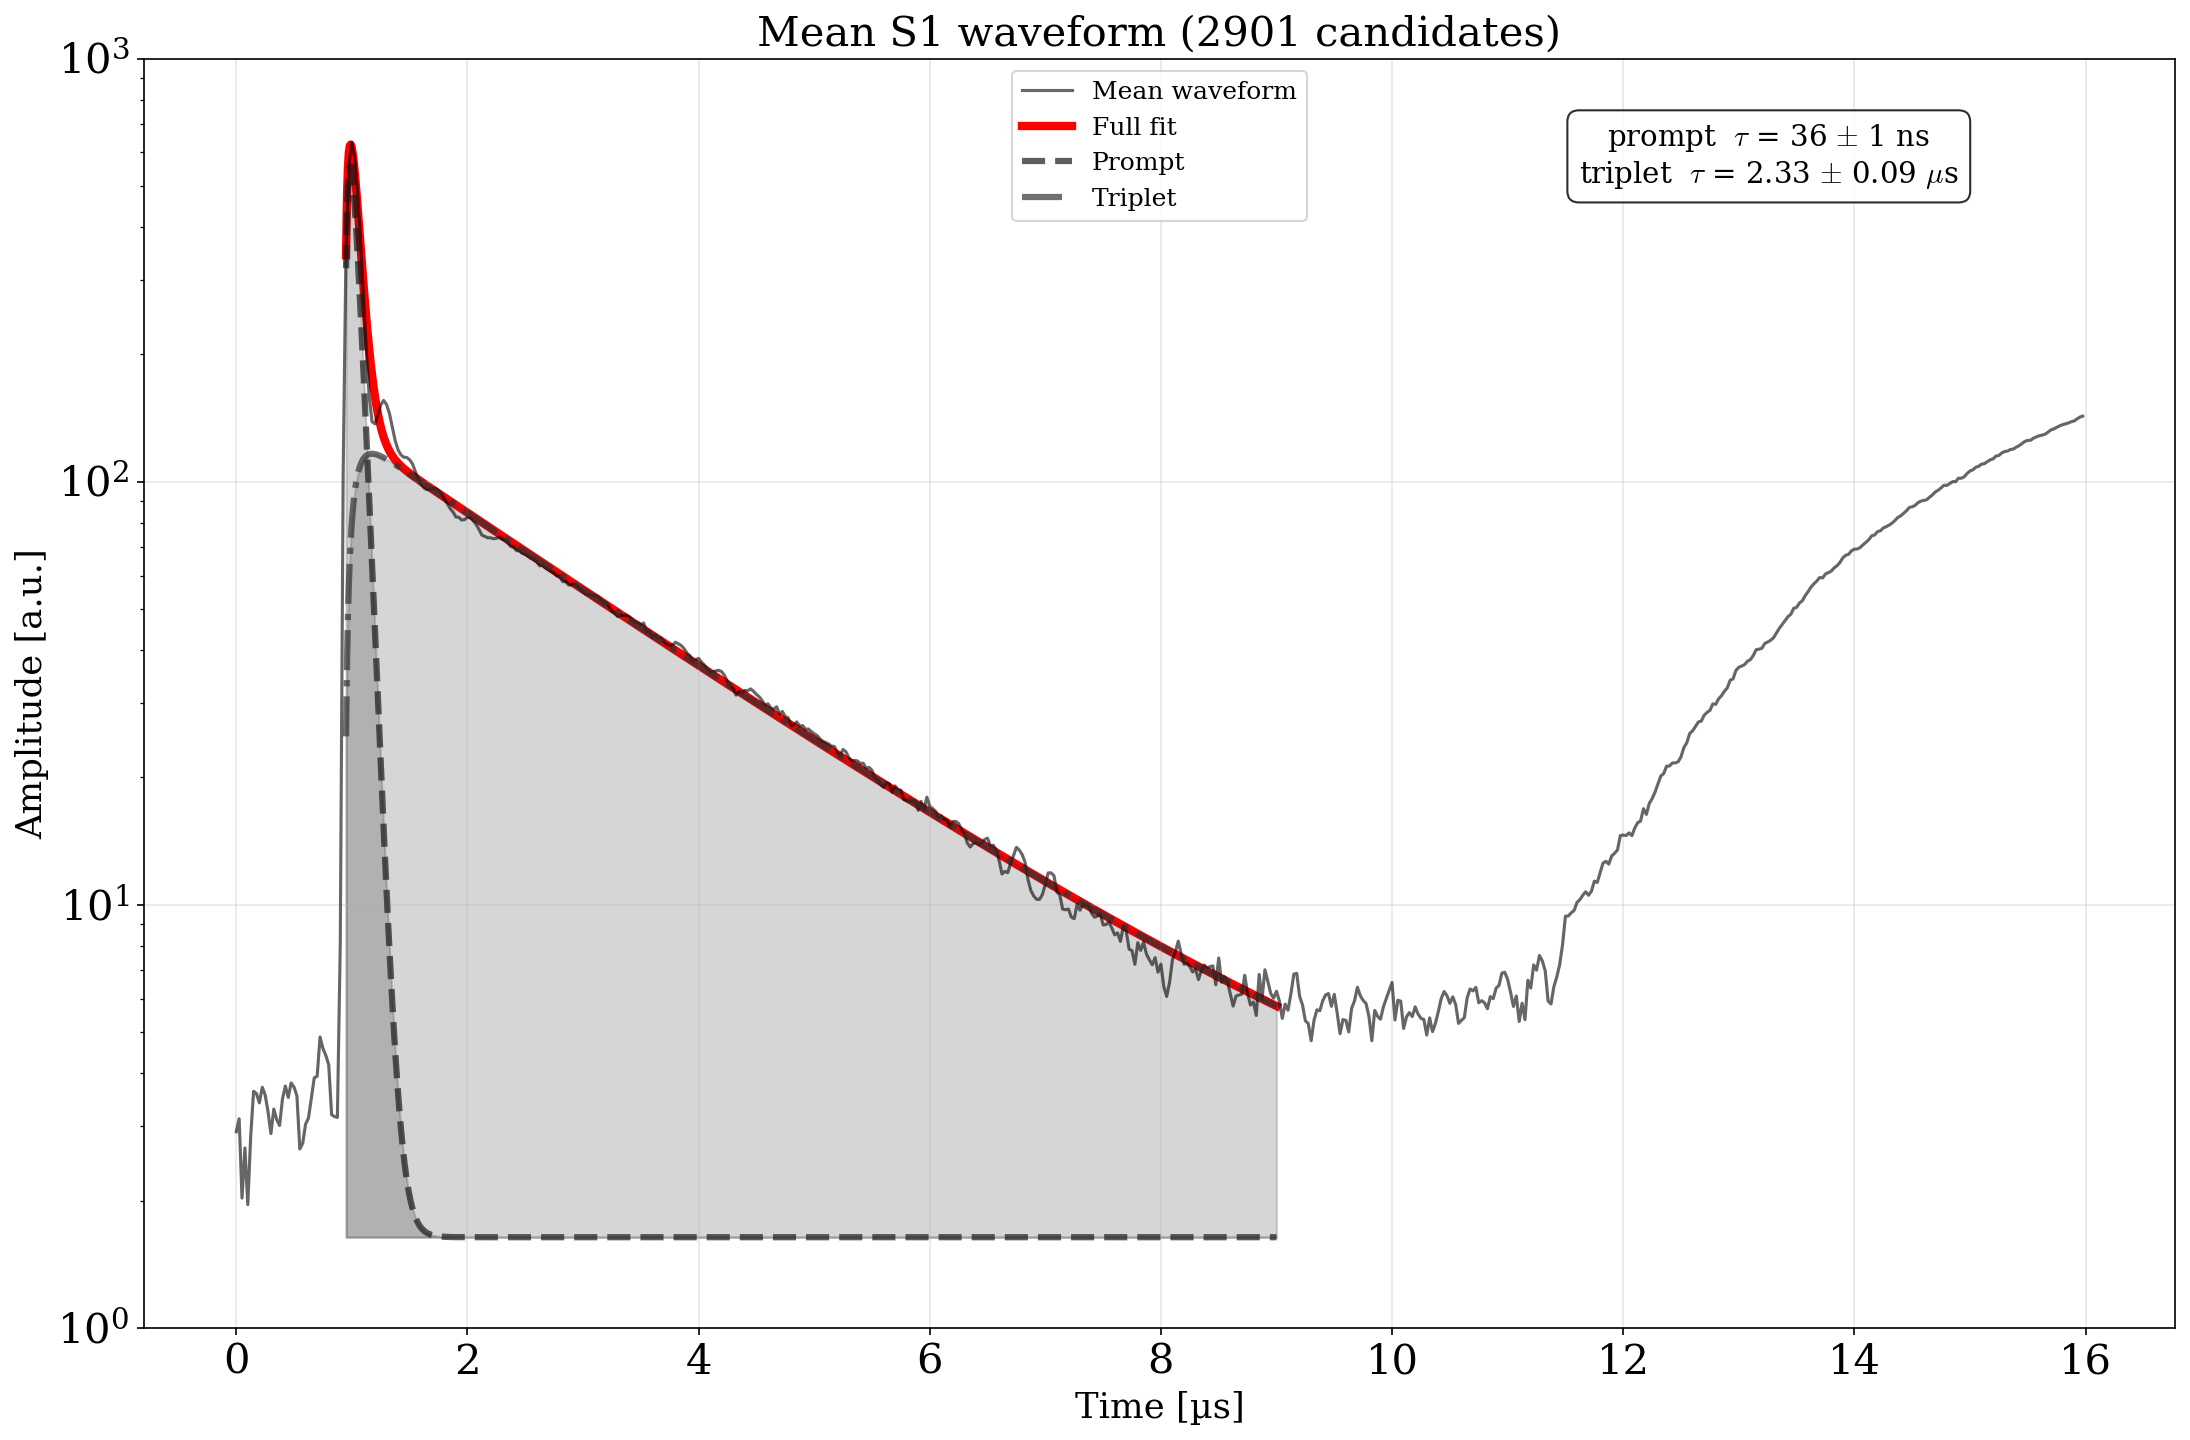

In [21]:

t = np.arange(0, (pre_us + post_us) * rebin_factor) / rebin_factor  # µs

fit_mask = (t >= pre_us - 0.05) & (t <= 9.)  # start just before the S1 peak
# fit_mask = (t >= pre_us - 0.05)   # start just before the S1 peak
t_fit    = t[fit_mask]
wf_fit   = mean_wf[fit_mask]

A_peak = wf_fit.max()
bl_est = np.median(mean_wf[:20])

#          A_s             tau_s     A_t               tau_t  t0                       bl
p0     = [A_peak * 0.30,   0.006,    A_peak * 0.70,   1.,    pre_us - 0.20,           bl_est]
bounds = ([0,              0.001,    0,               0.3,   pre_us - 0.50,          -np.inf],
          [np.inf,         0.300,    np.inf,          5.,    t_fit[0],                np.inf])

popt, pcov = curve_fit(pulse_model, t_fit, wf_fit, p0=p0, bounds=bounds, maxfev=10000)
perr = np.sqrt(np.diag(pcov))

A_s_fit, tau_s_fit, A_t_fit, tau_t_fit, t0_fit, bl_fit = popt

print(f"A_prompt   = {A_s_fit:.2f}  ± {perr[0]:.2f}")
print(f"tau_prompt = {tau_s_fit*1e3:.1f} ns  ± {perr[1]*1e3:.1f} ns")
print(f"A_triplet   = {A_t_fit:.2f}  ± {perr[2]:.2f}")
print(f"tau_triplet = {tau_t_fit:.3f} µs  ± {perr[3]:.3f} µs")
print(f"t0          = {t0_fit:.4f} µs  ± {perr[4]*1e3:.1f} ns")
print(f"bl          = {bl_fit:.1f}  ± {perr[5]:.2f}")

# reconstruct components on fine grid
t_fine = np.linspace(t_fit[0], t_fit[-1], 1000)
u_fine = t_fine - t0_fit
mf     = u_fine > 0

h_s_fine = np.zeros_like(t_fine)
h_s_fine[mf] = _conv_rd(u_fine[mf], 0.001, tau_s_fit, 0.001, 0.064)
area = np.trapz(h_s_fine, x=t_fine)
if area > 0: h_s_fine *= A_s_fit / area

h_t_fine = np.zeros_like(t_fine)
h_t_fine[mf] = _conv_rd(u_fine[mf], 0.001, tau_t_fit, 0.001, 0.064)
area = np.trapz(h_t_fine, x=t_fine)
if area > 0: h_t_fine *= A_t_fit / area

col_prompt = colors[1]
col_triplet = colors[2]

fig, ax = plt.subplots(figsize=(15, 10), dpi=150)

ax.plot(t, mean_wf, '-', lw=1.5, color='black', alpha=0.6, label='Mean waveform')
ax.plot(t_fine, pulse_model(t_fine, *popt), '-', lw=4, color='red', label='Full fit', zorder=1)

ax.plot(t_fine, h_s_fine + bl_fit, '--', lw=3, alpha=0.7, color=col_prompt, label='Prompt')
ax.fill_between(t_fine, bl_fit, h_s_fine + bl_fit, alpha=0.2, color=col_prompt)
ax.plot(t_fine, h_t_fine + bl_fit, '-.', lw=3, alpha=0.7, color=col_triplet, label='Triplet')
ax.fill_between(t_fine, bl_fit, h_t_fine + bl_fit, alpha=0.2, color=col_triplet)

# ax.axvline(t0_fit, color='k', ls=':', alpha=0.4, label=f't$_0$ = {t0_fit:.2f} µs')
ax.axhline(0, color='k', ls=':', alpha=0.3)

ax.annotate(
    fr"prompt  $\tau$ = {tau_s_fit*1e3:.0f} $\pm$ {perr[1]*1e3:.0f} ns" + "\n"
    fr"triplet  $\tau$ = {tau_t_fit:.2f} $\pm$ {perr[3]:.2f} $\mu$s",
    xy=(0.80, 0.95), xycoords='axes fraction',
    ha='center', va='top', fontsize=font_size * 0.70,
    bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.82),
)

ax.set_xlabel('Time [µs]', fontsize=font_size * 0.85)
ax.set_ylabel('Amplitude [a.u.]', fontsize=font_size * 0.85)
ax.set_title(f'Mean S1 waveform ({len(all_cuts)} candidates)', fontsize=font_size)
ax.set_yscale('log')
ax.set_ylim(bottom=max(1, wf_fit[wf_fit > 0].min() * 0.1), top=1e3)
ax.legend(loc='upper center', fontsize=font_size * 0.60)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Systematic window: [7.0, 11.0] µs  (17 points)
  τ_prompt = 36.4 ± 1.0 (stat) ± 0.0 (syst)  ns
  τ_triplet = 2.334 ± 0.090 (stat) ± 0.022 (syst)  µs


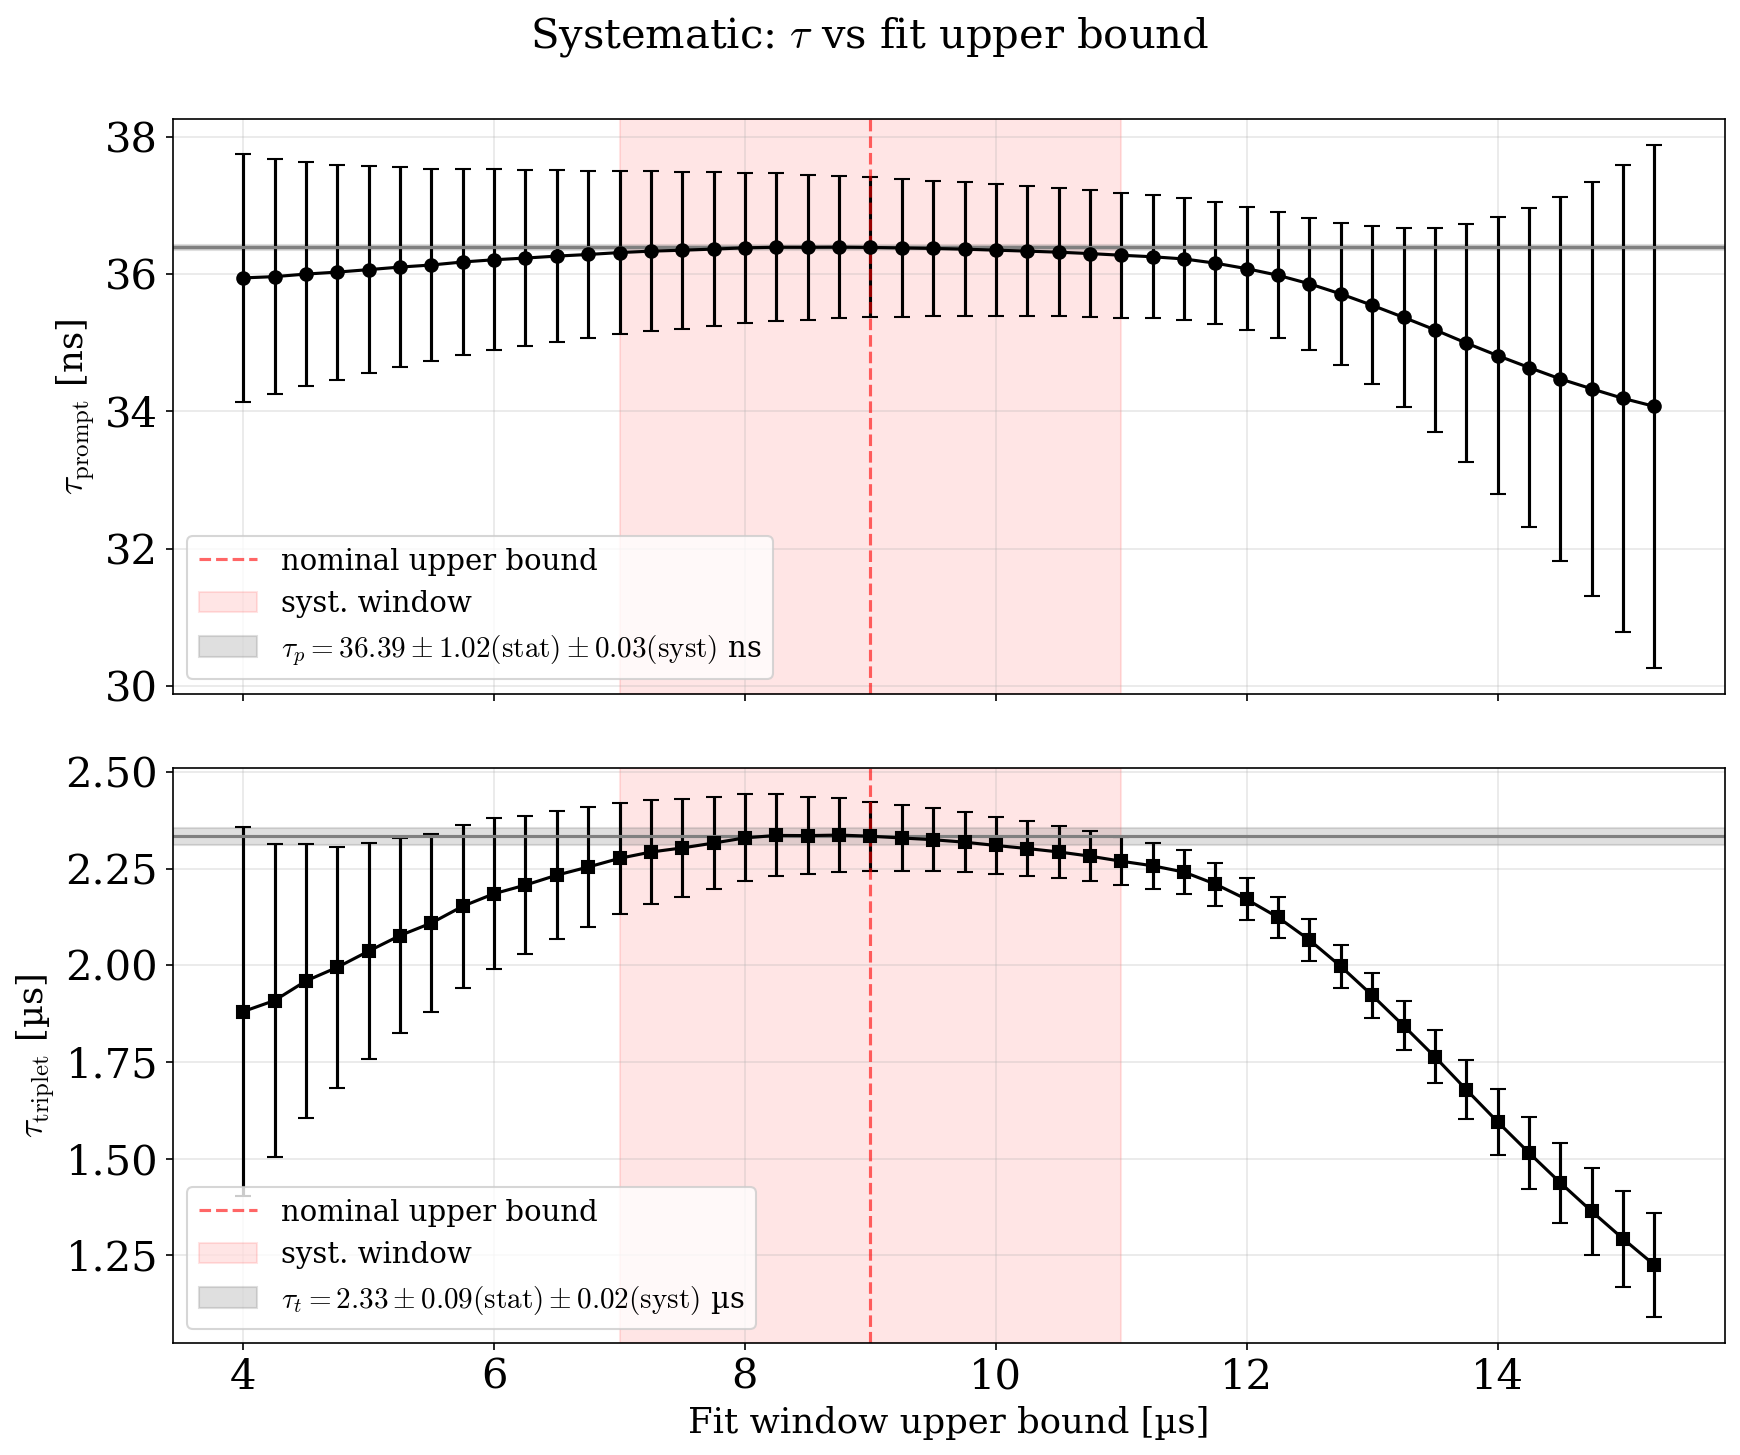

In [23]:
# Systematic scan: fitted tau vs upper bound of fit window
nom_upper_bound = 9.    # µs — nominal upper bound used in the main fit
syst_window     = 2.0   # µs — half-width of window for systematic estimate

upper_bounds = np.arange(4.0, post_us + 0.5, 0.25)  # µs

t_scan = np.arange(0, (pre_us + post_us) * rebin_factor) / rebin_factor

scan_tau_s   = []
scan_tau_t   = []
scan_err_s   = []
scan_err_t   = []
scan_ub_good = []

for ub in upper_bounds:
    mask = (t_scan >= pre_us - 0.05) & (t_scan <= ub)
    if mask.sum() < 10:
        continue

    t_f  = t_scan[mask]
    wf_f = mean_wf[mask]

    A_peak = wf_f.max()
    bl_est = np.median(mean_wf[:20])

    p0     = [A_peak * 0.30, 0.006, A_peak * 0.70, 1., pre_us - 0.20, bl_est]
    bounds = ([0, 0.001, 0, 0.3, pre_us - 0.50, -np.inf],
              [np.inf, 0.300, np.inf, 5., t_f[0], np.inf])

    try:
        popt_s, pcov_s = curve_fit(pulse_model, t_f, wf_f, p0=p0, bounds=bounds, maxfev=10000)
        perr_s = np.sqrt(np.diag(pcov_s))
        scan_tau_s.append(popt_s[1] * 1e3)   # ns
        scan_tau_t.append(popt_s[3])          # µs
        scan_err_s.append(perr_s[1] * 1e3)
        scan_err_t.append(perr_s[3])
        scan_ub_good.append(ub)
    except Exception:
        pass

scan_ub_good = np.array(scan_ub_good)
scan_tau_s   = np.array(scan_tau_s)
scan_tau_t   = np.array(scan_tau_t)
scan_err_s   = np.array(scan_err_s)
scan_err_t   = np.array(scan_err_t)

# ── Uncertainties ──────────────────────────────────────────────────────────────
# Central value : τ at the nominal upper bound
# σ_stat        : fit error at that point (from covariance matrix)
# σ_syst        : std of τ across the window — how much the result shifts
#                 when the upper bound is varied (std, not std/√N)
# σ_total       : sqrt(σ_stat² + σ_syst²)

nom_idx   = np.argmin(np.abs(scan_ub_good - nom_upper_bound))
tau_nom_s = scan_tau_s[nom_idx]
stat_s    = scan_err_s[nom_idx]

tau_nom_t = scan_tau_t[nom_idx]
stat_t    = scan_err_t[nom_idx]

in_window = (scan_ub_good >= nom_upper_bound - syst_window) & \
            (scan_ub_good <= nom_upper_bound + syst_window)

syst_s = scan_tau_s[in_window].std()
syst_t = scan_tau_t[in_window].std()
tot_s  = np.sqrt(stat_s**2 + syst_s**2)
tot_t  = np.sqrt(stat_t**2 + syst_t**2)

print(f"Systematic window: [{nom_upper_bound-syst_window:.1f}, {nom_upper_bound+syst_window:.1f}] µs  ({in_window.sum()} points)")
print(f"  τ_prompt = {tau_nom_s:.1f} ± {stat_s:.1f} (stat) ± {syst_s:.1f} (syst)  ns")
print(f"  τ_triplet = {tau_nom_t:.3f} ± {stat_t:.3f} (stat) ± {syst_t:.3f} (syst)  µs")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, dpi=150)

# ── prompt
ax1.errorbar(scan_ub_good, scan_tau_s, yerr=scan_err_s, fmt='o-', color='black', capsize=4)
ax1.axvline(nom_upper_bound, color='red', ls='--', alpha=0.6, label='nominal upper bound')
ax1.axvspan(nom_upper_bound - syst_window, nom_upper_bound + syst_window,
            alpha=0.10, color='red', label='syst. window')
ax1.axhline(tau_nom_s, color='grey', ls='-', lw=1.5)
ax1.axhspan(tau_nom_s - syst_s, tau_nom_s + syst_s, alpha=0.25, color='grey',
            label=fr'$\tau_p={tau_nom_s:.2f}\pm{stat_s:.2f}({{\rm stat}})\pm{syst_s:.2f}({{\rm syst}})$ ns')
ax1.set_ylabel(r'$\tau_{\rm prompt}$ [ns]', fontsize=font_size * 0.85)
ax1.legend(fontsize=font_size * 0.70, loc='lower left')
ax1.grid(True, alpha=0.3)

# ── triplet
ax2.errorbar(scan_ub_good, scan_tau_t, yerr=scan_err_t, fmt='s-', color='black', capsize=4)
ax2.axvline(nom_upper_bound, color='red', ls='--', alpha=0.6, label='nominal upper bound')
ax2.axvspan(nom_upper_bound - syst_window, nom_upper_bound + syst_window,
            alpha=0.10, color='red', label='syst. window')
ax2.axhline(tau_nom_t, color='grey', ls='-', lw=1.5)
ax2.axhspan(tau_nom_t - syst_t, tau_nom_t + syst_t, alpha=0.25, color='grey',
            label=fr'$\tau_t={tau_nom_t:.2f}\pm{stat_t:.2f}({{\rm stat}})\pm{syst_t:.2f}({{\rm syst}})$ µs')
ax2.set_ylabel(r'$\tau_{\rm triplet}$ [µs]', fontsize=font_size * 0.85)
ax2.set_xlabel('Fit window upper bound [µs]', fontsize=font_size * 0.85)
ax2.legend(fontsize=font_size * 0.70, loc='lower left')
ax2.grid(True, alpha=0.3)

fig.suptitle('Systematic: $\\tau$ vs fit upper bound', fontsize=font_size)
plt.tight_layout()
plt.show()
